In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
import seaborn as sns

In [2]:
# Load data
OE_detailed = pd.read_parquet(Path("../data/processed/oe_detailed.parquet"))

# Rename Travel_Distance column to Distance for df OE_detailed
OE_detailed = OE_detailed.rename(columns={'Travel_Distance': 'Distance'})
# Timestamp to timestamp
OE_detailed["Timestamp"] = pd.to_datetime(OE_detailed["Timestamp"])
# UserID to int
OE_detailed["UserID"] = OE_detailed["UserID"].astype(int)

In [3]:
display(OE_detailed.head(3))


,ActivityCode,UserID,WorkCode,AssignmentID,ProductID,Quantity,Timestamp,LocationID,Prev_Timestamp,Prev_LocationID,...,Prev_Bay,Prev_Level,Prev_Slot,Aisle2,Bay2,Prev_Aisle2,Prev_Bay2,LocKey,PrevLocKey,Distance
0,PickPut,143,30,7717848,49658,160,2025-09-08 12:11:50.830,35192,NaT,<NA>,...,<NA>,<NA>,<NA>,40,19,<NA>,<NA>,40|19|||,<NA>|<NA>|||,NaN
1,PickPut,143,30,7717860,460,50,2025-09-08 12:12:18.127,422,2025-09-08 12:11:50.830,35192,...,19,2,2,40,18,40,19,40|18|||,40|19|||,21.0
2,PickPut,143,30,7717908,460,100,2025-09-08 12:15:46.650,422,2025-09-08 12:12:18.127,422,...,18,2,1,40,18,40,18,40|18|||,40|18|||,0.0


In [4]:
# Load distance matrix
Distance = pd.read_csv("../data/distance_matrices/distance_matrix_OE.csv", index_col=0)

display(Distance.head(3))

,08|03|||,08|05|||,08|07|||,08|09|||,10|04|||,10|06|||,10|08|||,10|10|||,10|12|||,10|14|||,...,|Start L3,|Start L4,|Start L5,|Start L6,|Start R2,|Start R3,|Start R4,|Start R5,|Start R6,|Start SB
08|03|||,0,414,389,364,304,287,271,255,240,223,...,1094,1068,897,953,1080,1045,1089,913,969,994
08|05|||,25,0,414,389,329,312,296,280,265,248,...,1119,1093,922,978,1104,1070,1113,938,994,1018
08|07|||,50,25,0,414,354,337,321,305,290,273,...,1144,1118,947,1003,1129,1095,1138,963,1019,1043


In [5]:
# extract df for user 143 on day 2025-09-08
user143_sep08 = OE_detailed[(OE_detailed["UserID"] == 143) & (OE_detailed["Timestamp"].dt.date == pd.to_datetime("2025-09-08").date())]
#length
print("Number of rows for User 143 on 2025-09-08:", len(user143_sep08))

Number of rows for User 143 on 2025-09-08: 622


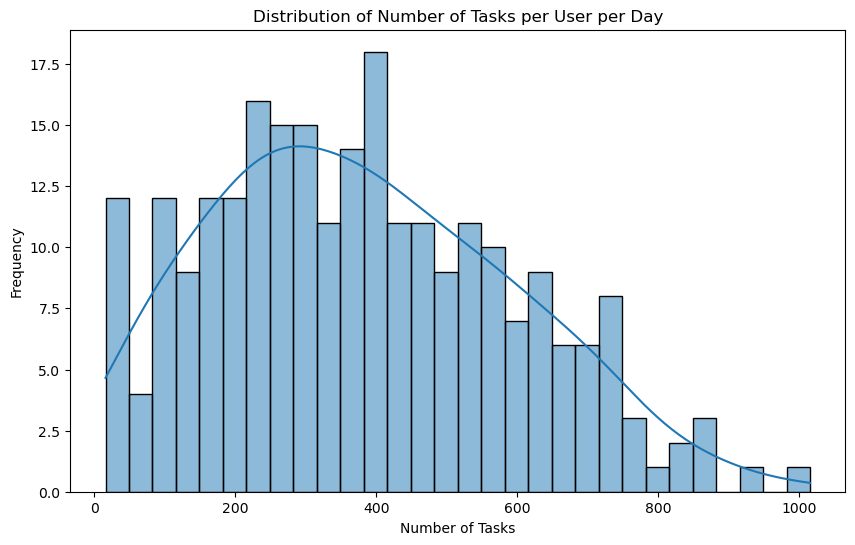

Mean number of tasks per user per day: 379.12
Median number of tasks per user per day: 361.0


In [43]:
# Distribution of Number of tasks per user per day
tasks_per_user_day = OE_detailed.groupby(["UserID", OE_detailed["Timestamp"].dt.date]).size().reset_index(name="num_tasks")
# Plot distribution of number of tasks per user per day
plt.figure(figsize=(10, 6))
sns.histplot(tasks_per_user_day["num_tasks"], bins=30, kde=True)
plt.title("Distribution of Number of Tasks per User per Day")
plt.xlabel("Number of Tasks")
plt.ylabel("Frequency")
plt.show()
# print mean and median number of tasks per user per day
mean_tasks = tasks_per_user_day["num_tasks"].mean()
median_tasks = tasks_per_user_day["num_tasks"].median()
print(f"Mean number of tasks per user per day: {mean_tasks:.2f}")
print(f"Median number of tasks per user per day: {median_tasks}")

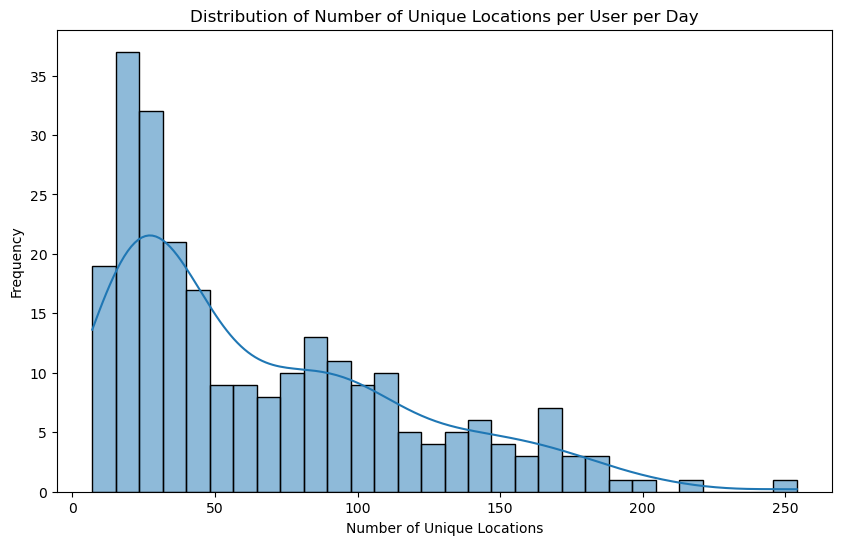

Mean number of unique locations per user per day: 66.43
Median number of unique locations per user per day: 47.0


In [44]:
unique_locations_per_user_day = OE_detailed.groupby(["UserID", OE_detailed["Timestamp"].dt.date])["LocKey"].nunique().reset_index(name="num_unique_locations")
# Plot distribution of number of unique locations per user per day
plt.figure(figsize=(10, 6))
sns.histplot(unique_locations_per_user_day["num_unique_locations"], bins=30, kde=True)
plt.title("Distribution of Number of Unique Locations per User per Day")
plt.xlabel("Number of Unique Locations")
plt.ylabel("Frequency")
plt.show()
# print mean and median number of unique locations per user per day
mean_unique_locations = unique_locations_per_user_day["num_unique_locations"].mean()
median_unique_locations = unique_locations_per_user_day["num_unique_locations"].median()
print(f"Mean number of unique locations per user per day: {mean_unique_locations:.2f}")
print(f"Median number of unique locations per user per day: {median_unique_locations}")

In [29]:
# extract the list of first 10 unique locations LocKey
unique_locations = user143_sep08["LocKey"].unique()[:10]
print("Unique locations (LocKey) for User 143 on 2025-09-08 (first 10 rows):", unique_locations)

Unique locations (LocKey) for User 143 on 2025-09-08 (first 10 rows): ['40|19|||' '40|18|||' '40|16|||' '40|14|||' '40|13|||' '40|15|||'
 '40|17|||' '40|20|||' '40|21|||' '40|12|||']


In [7]:
from functools import lru_cache

def held_karp_path_fixed_start(locations, dist_df):
    """
    Exact shortest Hamiltonian path for asymmetric distances.
    Start fixed at index 0; visit all nodes exactly once; end anywhere.
    Returns (best_cost, route_indices)
    """
    n = len(locations)
    mat = [[float(dist_df.loc[locations[i], locations[j]]) for j in range(n)] for i in range(n)]
    START = 0
    FULL = (1 << n) - 1

    @lru_cache(None)
    def dp(mask, last):
        # min cost to start at START, visit exactly mask (includes START and last), end at last
        if mask == (1 << START) and last == START:
            return 0.0
        if not (mask & (1 << last)) or not (mask & (1 << START)):
            return float("inf")
        if last == START and mask != (1 << START):
            return float("inf")

        prev_mask = mask & ~(1 << last)
        best = float("inf")
        m = prev_mask
        while m:
            p = (m & -m).bit_length() - 1
            best = min(best, dp(prev_mask, p) + mat[p][last])
            m &= (m - 1)
        return best

    # end anywhere (no return to START)
    best_cost = float("inf")
    best_last = None
    for last in range(n):
        if last == START:
            continue
        c = dp(FULL, last)
        if c < best_cost:
            best_cost = c
            best_last = last

    # Reconstruct
    route = [None] * n
    route[-1] = best_last
    mask = FULL
    last = best_last
    for pos in range(n - 2, -1, -1):
        route[pos] = None
        prev_mask = mask & ~(1 << last)
        if prev_mask == (1 << START):
            route[pos] = START
            break

        best_p = None
        best_val = float("inf")
        m = prev_mask
        while m:
            p = (m & -m).bit_length() - 1
            val = dp(prev_mask, p) + mat[p][last]
            if val < best_val:
                best_val = val
                best_p = p
            m &= (m - 1)
        route[pos] = best_p
        mask = prev_mask
        last = best_p

    return best_cost, route

In [30]:
# compute actual cost of unique_locations in original order
actual_cost = 0.0
for i in range(len(unique_locations) - 1):
    loc1 = unique_locations[i]
    loc2 = unique_locations[i + 1]
    actual_cost += Distance.loc[loc1, loc2]
print("Actual cost:", actual_cost)
# print actual route again
# print("Actual route:", unique_locations)
# print actual route with distances in between
print("Actual route:")
for i in range(len(unique_locations) - 1):
    loc1 = unique_locations[i]
    loc2 = unique_locations[i + 1]
    dist = Distance.loc[loc1, loc2]
    print(f"{loc1} -> {loc2}: {dist}")

Actual cost: 495.0
Actual route:
40|19||| -> 40|18|||: 21
40|18||| -> 40|16|||: 43
40|16||| -> 40|14|||: 43
40|14||| -> 40|13|||: 21
40|13||| -> 40|15|||: 43
40|15||| -> 40|17|||: 43
40|17||| -> 40|20|||: 64
40|20||| -> 40|21|||: 23
40|21||| -> 40|12|||: 194


In [50]:
best_cost, route = held_karp_path_fixed_start(unique_locations, Distance)
print("Best cost:", best_cost)
best_route = [unique_locations[i] for i in route]
# print("Best route:", best_route)
# print best route with distances in between
print("Best route:")
for i in range(len(best_route) - 1):
    loc1 = best_route[i]
    loc2 = best_route[i + 1]
    dist = Distance.loc[loc1, loc2]
    print(f"{loc1} -> {loc2}: {dist}")

Best cost: 234.0
Best route:
40|19||| -> 40|20|||: 21
40|20||| -> 40|21|||: 23
40|21||| -> 40|18|||: 64
40|18||| -> 40|17|||: 21
40|17||| -> 40|16|||: 21
40|16||| -> 40|15|||: 21
40|15||| -> 40|14|||: 21
40|14||| -> 40|13|||: 21
40|13||| -> 40|12|||: 21


Thank you guys for the wishes, but my interview's actually cancelled because of the storm, so I'll probably need to travel again the week after spring break for it☹️ 
I explored the best route for a bit, I'll put my stuff in the slides
For 
The users don't always follow the best route and sequence of task

In [49]:
# for each user on 2025-09-08, selected the first 10 unique locations, compute the unique locations, compute the actual cost of the route, compute the optimal route and its cost, and compute average cost improvement of optimal route compared to actual route
results = []
for user_id in OE_detailed["UserID"].unique():
    user_df = OE_detailed[(OE_detailed["UserID"] == user_id) & (OE_detailed["Timestamp"].dt.date == pd.to_datetime("2025-09-08").date())]
    unique_locs = user_df["LocKey"].unique()[:15]
    if len(unique_locs) < 2:
        continue
    actual_dist = 0.0
    for i in range(len(unique_locs) - 1):
        loc1 = unique_locs[i]
        loc2 = unique_locs[i + 1]
        actual_dist += Distance.loc[loc1, loc2]
    best_dist, route = held_karp_path_fixed_start(unique_locs, Distance)
    improve = actual_dist - best_dist
    percent_improve = improve / actual_dist if actual_dist > 0 else 0
    percent_improve = round(percent_improve * 100, 2)
    results.append((user_id, actual_dist, best_dist, improve, percent_improve))
results_df = pd.DataFrame(results, columns=["UserID", "TotalDist", "ShortestPath", "Improve", "Percent"])
print(results_df.head(10))
print("Average improvement:", round((results_df["Improve"].mean()/10), 2), "ft/task")

   UserID  TotalDist  ShortestPath  Improve  Percent
0     143      654.0         393.0    261.0    39.91
1     217     3934.0        3021.0    913.0    23.21
2     221      612.0         309.0    303.0    49.51
3     262      420.0         321.0     99.0    23.57
4     322     2987.0        2663.0    324.0    10.85
5     348     5521.0        3689.0   1832.0    33.18
6     390     2778.0        1879.0    899.0    32.36
7     412      836.0         568.0    268.0    32.06
8     414     1427.0         797.0    630.0    44.15
9     419     5128.0        3747.0   1381.0    26.93
Average improvement: 66.7 ft/task
